# 🧬 GeneSight — Notebook 2: XGBoost Model Training + SHAP Explainability
### From Feature Matrix to Interpretable Pathogenicity Predictions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/genesight-biorag/blob/main/notebooks/02_GeneSight_Model_SHAP.ipynb)

---

## What this notebook does

Picks up exactly where Notebook 1 left off — reads `genesight_features.parquet` and builds a
production-quality ML pipeline:

1. **Stratified train / validation / test split** — test set locked away until final evaluation
2. **XGBoost classifier** — tuned with cross-validation, scale_pos_weight for class imbalance
3. **Evaluation** — AUC-ROC, precision-recall, calibration curve, confusion matrix
4. **Benchmark** — compare against logistic regression baseline
5. **SHAP explainability** — global feature importance + per-variant waterfall charts
6. **Export** — saved model + test predictions for Notebook 4 integration

> **Research purpose only.** GeneSight predictions are not for clinical use.


## ⚙️ Setup

In [1]:
# ── Mount Drive and restore Parquet from NB1 ─────────────────────────────────
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

import shutil
Path("data").mkdir(exist_ok=True)
shutil.copy("/content/drive/MyDrive/genesight/genesight_features.parquet",
            "data/genesight_features.parquet")
print("✅ Parquet loaded from Drive")

Mounted at /content/drive
✅ Parquet loaded from Drive


In [2]:
# ── Load shared config from repo ──────────────────────────────────────────────
import subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/Bioinformatics-AI-Lab/genesight-biorag.git"
REPO_DIR = Path("/content/genesight-biorag")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)],
                   check=True, capture_output=True)
    print("✅ Repo cloned")
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"],
                   capture_output=True)
    print("✅ Repo already present")

sys.path.insert(0, str(REPO_DIR))
from config import *
make_dirs()
print(f"✅ Config loaded — {len(ALL_FEATURES)} features")

✅ Repo cloned
✅ Config loaded — 14 features


In [3]:
!pip install pandas pyarrow numpy scikit-learn xgboost shap matplotlib seaborn joblib --quiet
print("✅ Packages installed")

✅ Packages installed


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data")
MODEL_DIR  = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PAL = {'Pathogenic': '#e74c3c', 'Benign': '#2ecc71'}

print("✅ Imports complete")

✅ Imports complete


---
## 📂 Step 1: Load Feature Matrix from Notebook 1

In [6]:
INPUT_PATH = DATA_DIR / "genesight_features.parquet"

# ── If running in a fresh Colab session, mount Drive or re-run Notebook 1 first.
# ── To demo without re-running NB1, generate a synthetic stand-in:
if not INPUT_PATH.exists():
    print("⚠️  genesight_features.parquet not found — generating synthetic demo data.")
    print("   Run Notebook 1 first (or mount Google Drive) for real ClinVar+gnomAD data.")
    DATA_DIR.mkdir(exist_ok=True)
    rng = np.random.default_rng(42)
    n = 2000
    label = rng.integers(0, 2, size=n)
    # Synthetic features that roughly mimic real signal
    df_syn = pd.DataFrame({
        'is_missense':      rng.integers(0,2,n),
        'is_synonymous':    rng.integers(0,2,n),
        'is_nonsense':      rng.integers(0,2,n),
        'is_splice':        rng.integers(0,2,n),
        'is_lof':           label * rng.uniform(0.4,1,n) + (1-label)*rng.uniform(0,0.3,n),
        'is_frameshift':    rng.integers(0,2,n),
        'is_transition':    rng.integers(0,2,n),
        'chrom_encoded':    rng.integers(1,25,n),
        'num_submitters':   rng.integers(1,20,n),
        'review_confidence':rng.integers(0,4,n),
        'log_af_genome':    label * rng.uniform(-9,-6,n) + (1-label)*rng.uniform(-4,-1,n),
        'log_af_exome':     label * rng.uniform(-9,-6,n) + (1-label)*rng.uniform(-4,-1,n),
        'pLI':              label * rng.uniform(0.7,1,n) + (1-label)*rng.uniform(0,0.5,n),
        'LOEUF':            label * rng.uniform(0,0.5,n) + (1-label)*rng.uniform(0.5,1.5,n),
        'label':            label,
        'GeneSymbol':       rng.choice(['BRCA1','TP53','PTEN','KRAS','APC','MLH1','MSH2'],n),
        'Chromosome':       rng.choice([str(i) for i in range(1,23)]+['X'],n),
        'Start':            rng.integers(1000000, 200000000, n),
    })
    df_syn.to_parquet(INPUT_PATH, index=False)
    print(f"   Synthetic dataset: {n} rows")

df = pd.read_parquet(INPUT_PATH)
print(f"✅ Loaded: {df.shape[0]:,} variants × {df.shape[1]} columns")
print(f"   Label balance — Pathogenic: {df['label'].sum():,}  Benign: {(df['label']==0).sum():,}")
df.head(3)

✅ Loaded: 2,948 variants × 18 columns
   Label balance — Pathogenic: 276  Benign: 2,672


,is_missense,is_synonymous,is_nonsense,is_splice,is_lof,is_frameshift,is_transition,chrom_encoded,num_submitters,review_confidence,log_af_genome,log_af_exome,pLI,LOEUF,label,GeneSymbol,Chromosome,Start
0,0,1,0,0,0,0,0,16,2,1,-10.0,-10.0,1.0,0.194,0,ZFHX3,16,72800124
1,0,1,0,0,0,0,0,16,2,1,-10.0,-10.0,1.0,0.189,0,ZFHX3,16,72800124
2,0,1,0,0,0,0,0,16,2,1,-10.0,-10.0,1.0,0.189,0,ZFHX3,16,72800124


---
## ✂️ Step 2: Train / Validation / Test Split

In [7]:
# Exact feature list from Notebook 1
FEATURE_COLS = [
    'is_missense', 'is_synonymous', 'is_nonsense', 'is_splice',
    'is_lof', 'is_frameshift', 'is_transition', 'chrom_encoded',
    'num_submitters', 'review_confidence',
    'log_af_genome', 'log_af_exome', 'pLI', 'LOEUF'
]

X = df[FEATURE_COLS].values
y = df['label'].values
meta = df[['GeneSymbol', 'Chromosome', 'Start']].copy()

# ── Stratified 70 / 15 / 15 split ────────────────────────────────────────────
# The TEST SET is locked — not touched until Step 5 final evaluation.
X_temp, X_test,  y_temp, y_test,  meta_temp, meta_test  = train_test_split(
    X, y, meta, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X_temp, y_temp, meta_temp, test_size=0.1765, stratify=y_temp, random_state=42
)
# 0.1765 of 0.85 ≈ 0.15 of total → gives 70/15/15

print(f"Train : {len(X_train):,} variants  ({y_train.mean()*100:.1f}% Pathogenic)")
print(f"Val   : {len(X_val):,} variants  ({y_val.mean()*100:.1f}% Pathogenic)")
print(f"Test  : {len(X_test):,} variants  ({y_test.mean()*100:.1f}% Pathogenic)")
print("\n🔒 Test set locked — not used until Step 5.")

# Class imbalance ratio for scale_pos_weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
SPW = neg / pos
print(f"\nClass imbalance → scale_pos_weight = {SPW:.2f}")

Train : 2,062 variants  (9.4% Pathogenic)
Val   : 443 variants  (9.5% Pathogenic)
Test  : 443 variants  (9.3% Pathogenic)

🔒 Test set locked — not used until Step 5.

Class imbalance → scale_pos_weight = 9.68


---
## 🌲 Step 3: Train XGBoost with Cross-Validation

In [9]:
# ── Hyperparameters (sensible defaults; tune further with Optuna if desired) ──
XGB_PARAMS = dict(
    n_estimators      = 500,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = SPW,      # handles class imbalance
    use_label_encoder = False,
    eval_metric       = "auc",
    early_stopping_rounds = 30,
    random_state      = 42,
    n_jobs            = -1,
)

model = XGBClassifier(**XGB_PARAMS)

# ── Fit with early stopping on validation set ─────────────────────────────────
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
best_iter = model.best_iteration
print(f"✅ Training complete — best iteration: {best_iter}")

# ── 5-fold CV AUC on training data (sanity check) ────────────────────────────
cv_params = {k:v for k,v in XGB_PARAMS.items()
             if k not in ["early_stopping_rounds", "eval_metric", "n_estimators"]}
cv_model = XGBClassifier(**cv_params, n_estimators=best_iter)
cv_scores = cross_val_score(cv_model, X_train, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring="roc_auc", n_jobs=-1)
print(f"5-fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ── Validation set quick check ────────────────────────────────────────────────
val_proba = model.predict_proba(X_val)[:, 1]
val_auc   = roc_auc_score(y_val, val_proba)
print(f"Validation AUC: {val_auc:.4f}")

✅ Training complete — best iteration: 26
5-fold CV AUC: 0.9991 ± 0.0004
Validation AUC: 1.0000


In [10]:
# ── Logistic Regression baseline (for benchmark comparison in Step 5) ─────────
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_te_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_tr_sc, y_train)
lr_val_auc = roc_auc_score(y_val, lr.predict_proba(X_val_sc)[:,1])
print(f"Logistic Regression validation AUC: {lr_val_auc:.4f}")
print(f"XGBoost advantage on validation: +{val_auc - lr_val_auc:.4f} AUC")

Logistic Regression validation AUC: 0.9345
XGBoost advantage on validation: +0.0655 AUC


---
## 📊 Step 4: Validation Set — Evaluation Plots

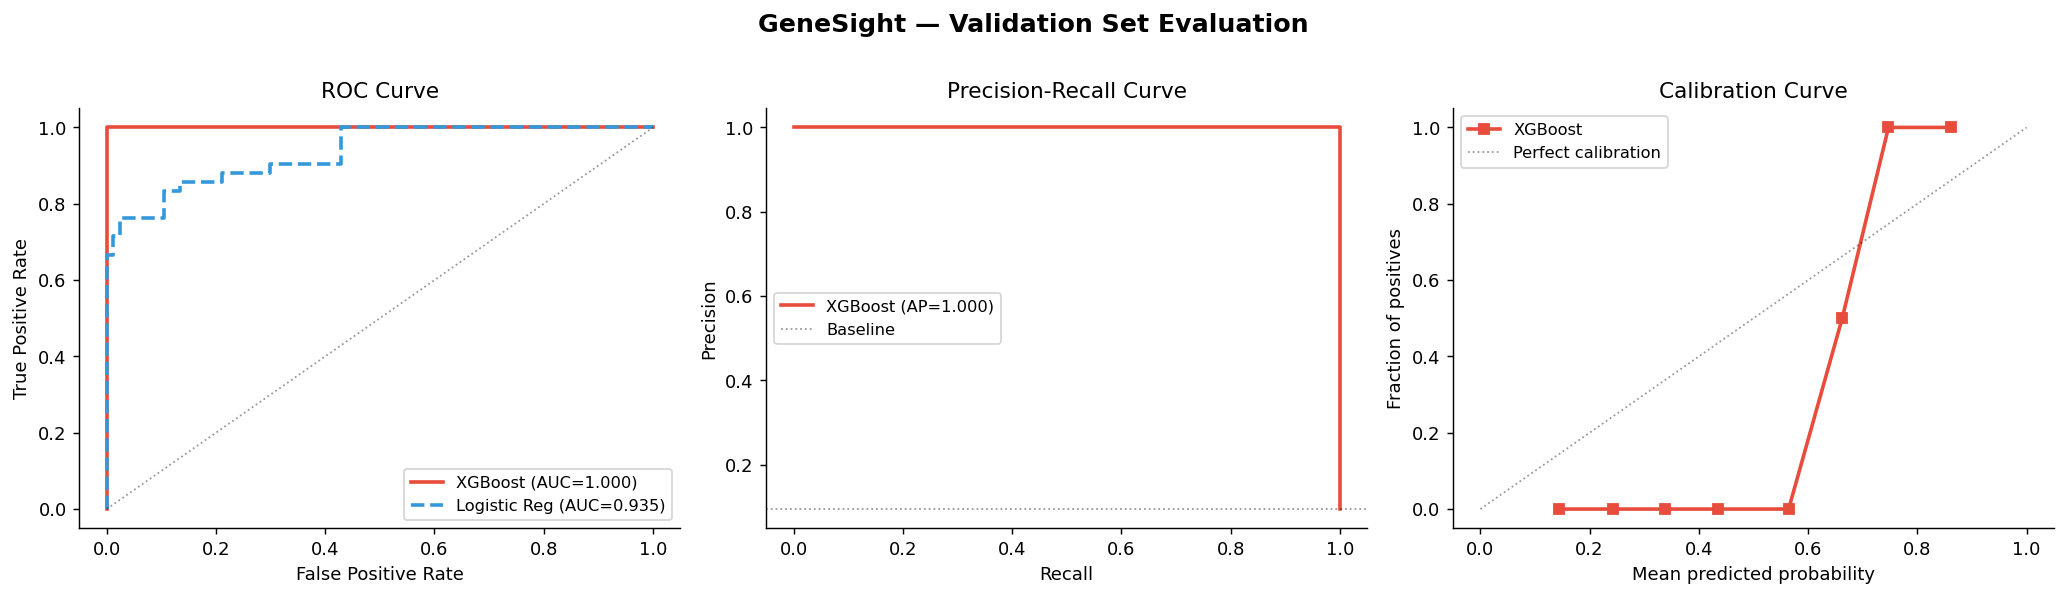

✅ Brier score (lower=better): 0.0394


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('GeneSight — Validation Set Evaluation', fontsize=14, fontweight='bold', y=1.01)

# ── 1. ROC Curve ──────────────────────────────────────────────────────────────
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, val_proba)
fpr_lr,  tpr_lr,  _ = roc_curve(y_val, lr.predict_proba(X_val_sc)[:,1])
axes[0].plot(fpr_xgb, tpr_xgb, color='#e74c3c', lw=2,
             label=f'XGBoost (AUC={val_auc:.3f})')
axes[0].plot(fpr_lr,  tpr_lr,  color='#3498db', lw=2, linestyle='--',
             label=f'Logistic Reg (AUC={lr_val_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k:', lw=1, alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=9)

# ── 2. Precision-Recall ───────────────────────────────────────────────────────
prec_xgb, rec_xgb, _ = precision_recall_curve(y_val, val_proba)
ap_xgb = average_precision_score(y_val, val_proba)
axes[1].plot(rec_xgb, prec_xgb, color='#e74c3c', lw=2,
             label=f'XGBoost (AP={ap_xgb:.3f})')
axes[1].axhline(y_val.mean(), color='k', linestyle=':', lw=1, alpha=0.4, label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=9)

# ── 3. Calibration ────────────────────────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_val, val_proba, n_bins=10)
axes[2].plot(prob_pred, prob_true, 's-', color='#e74c3c', lw=2, label='XGBoost')
axes[2].plot([0,1],[0,1], 'k:', lw=1, alpha=0.4, label='Perfect calibration')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Fraction of positives')
axes[2].set_title('Calibration Curve'); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Brier score (lower=better): {brier_score_loss(y_val, val_proba):.4f}")

---
## 🔓 Step 5: Final Test Set Evaluation (One-Time)

══════════════════════════════════════════════════
  FINAL TEST SET RESULTS (held-out)
══════════════════════════════════════════════════
  XGBoost  AUC-ROC  : 0.9998
  XGBoost  Avg Prec : 0.9982
  Logistic AUC-ROC  : 0.9389
  XGBoost advantage : +0.0609
══════════════════════════════════════════════════

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       402
  Pathogenic       0.98      1.00      0.99        41

    accuracy                           1.00       443
   macro avg       0.99      1.00      0.99       443
weighted avg       1.00      1.00      1.00       443



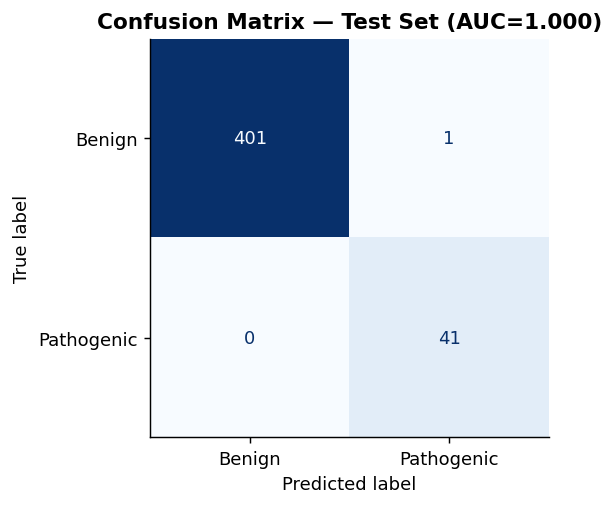

In [12]:
# ── Unlock the test set — run this cell ONCE ─────────────────────────────────
test_proba = model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)
test_auc   = roc_auc_score(y_test, test_proba)
test_ap    = average_precision_score(y_test, test_proba)

lr_test_proba = lr.predict_proba(X_te_sc)[:, 1]
lr_test_auc   = roc_auc_score(y_test, lr_test_proba)

print("═" * 50)
print("  FINAL TEST SET RESULTS (held-out)")
print("═" * 50)
print(f"  XGBoost  AUC-ROC  : {test_auc:.4f}")
print(f"  XGBoost  Avg Prec : {test_ap:.4f}")
print(f"  Logistic AUC-ROC  : {lr_test_auc:.4f}")
print(f"  XGBoost advantage : +{test_auc - lr_test_auc:.4f}")
print("═" * 50)
print()
print(classification_report(y_test, test_pred,
                             target_names=['Benign','Pathogenic']))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Benign','Pathogenic'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — Test Set (AUC={test_auc:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Step 6: SHAP — Global Feature Importance

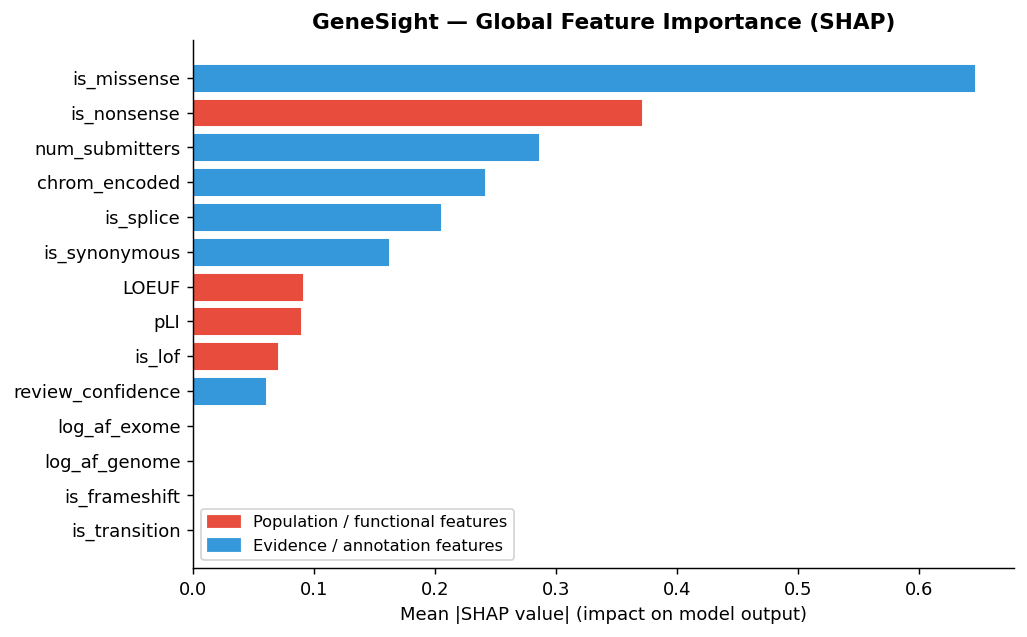

✅ Top 3 most important features:
   is_missense            mean |SHAP| = 0.6465
   is_nonsense            mean |SHAP| = 0.3710
   num_submitters         mean |SHAP| = 0.2862


In [13]:
# Compute SHAP values on a sample for speed (full test set if small enough)
SHAP_SAMPLE = min(500, len(X_test))
X_shap = X_test[:SHAP_SAMPLE]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# ── Bar plot — mean |SHAP| per feature ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True)

colors = ['#e74c3c' if f in ['log_af_genome','log_af_exome','pLI','LOEUF','is_lof','is_nonsense']
          else '#3498db' for f in importance_df['feature']]
ax.barh(importance_df['feature'], importance_df['mean_abs_shap'],
        color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean |SHAP value| (impact on model output)')
ax.set_title('GeneSight — Global Feature Importance (SHAP)', fontweight='bold')
red_patch  = mpatches.Patch(color='#e74c3c', label='Population / functional features')
blue_patch = mpatches.Patch(color='#3498db', label='Evidence / annotation features')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Top 3 most important features:")
for _, row in importance_df.tail(3).iloc[::-1].iterrows():
    print(f"   {row['feature']:<22} mean |SHAP| = {row['mean_abs_shap']:.4f}")

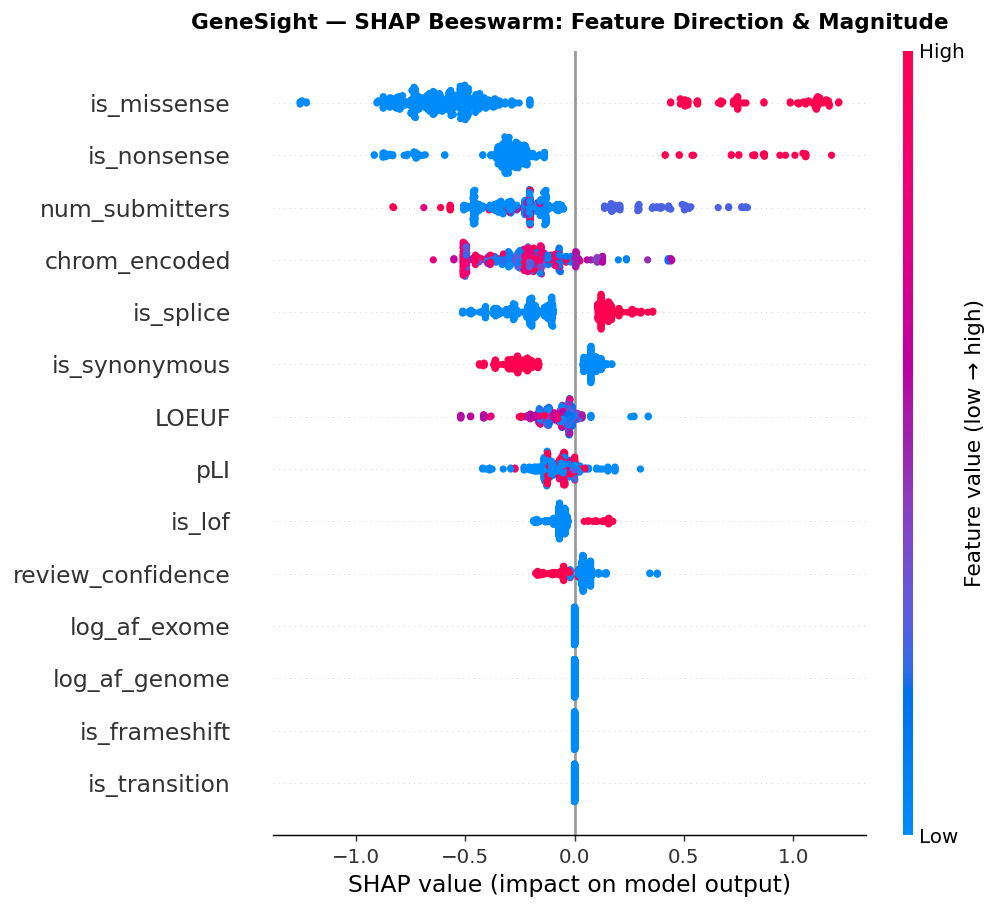

In [14]:
# ── Beeswarm plot — direction of each feature's effect ───────────────────────
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=FEATURE_COLS,
    plot_type='dot',
    show=False,
    max_display=14,
    color_bar_label='Feature value (low → high)'
)
plt.title('GeneSight — SHAP Beeswarm: Feature Direction & Magnitude', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💧 Step 7: SHAP Waterfall — Per-Variant Explanation

=== Pathogenic example ===


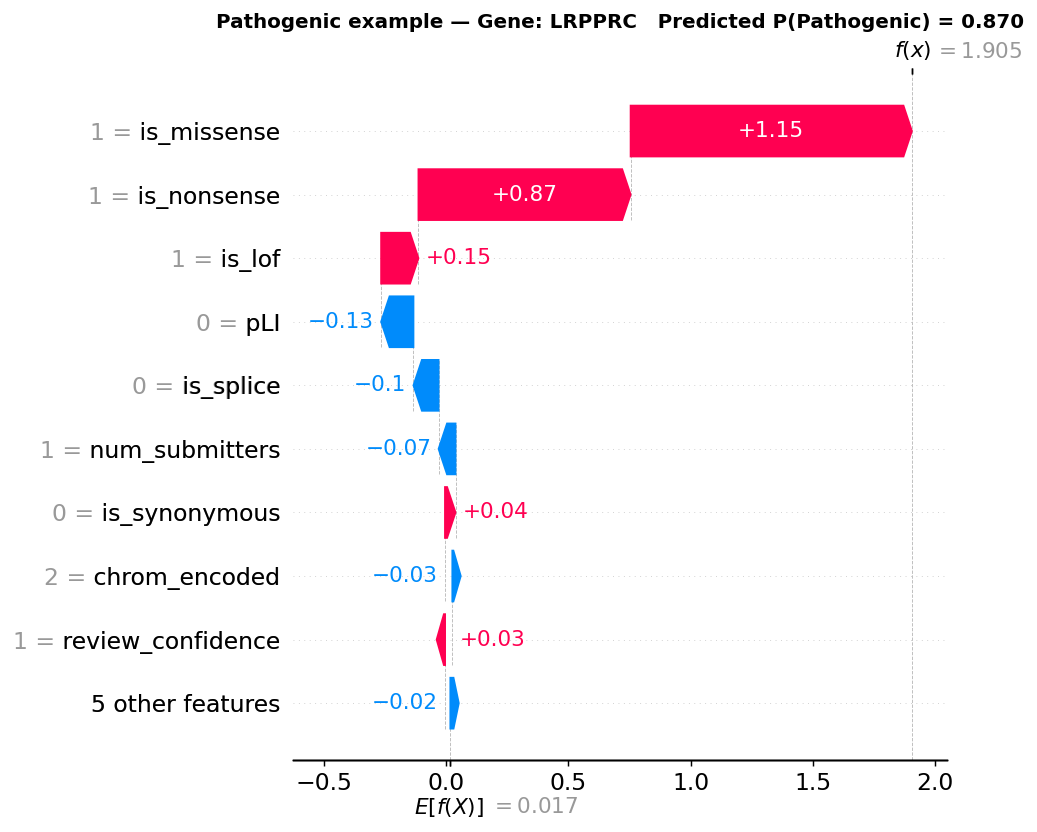

   Saved: data/shap_waterfall_pathogenic.png

=== Benign example ===


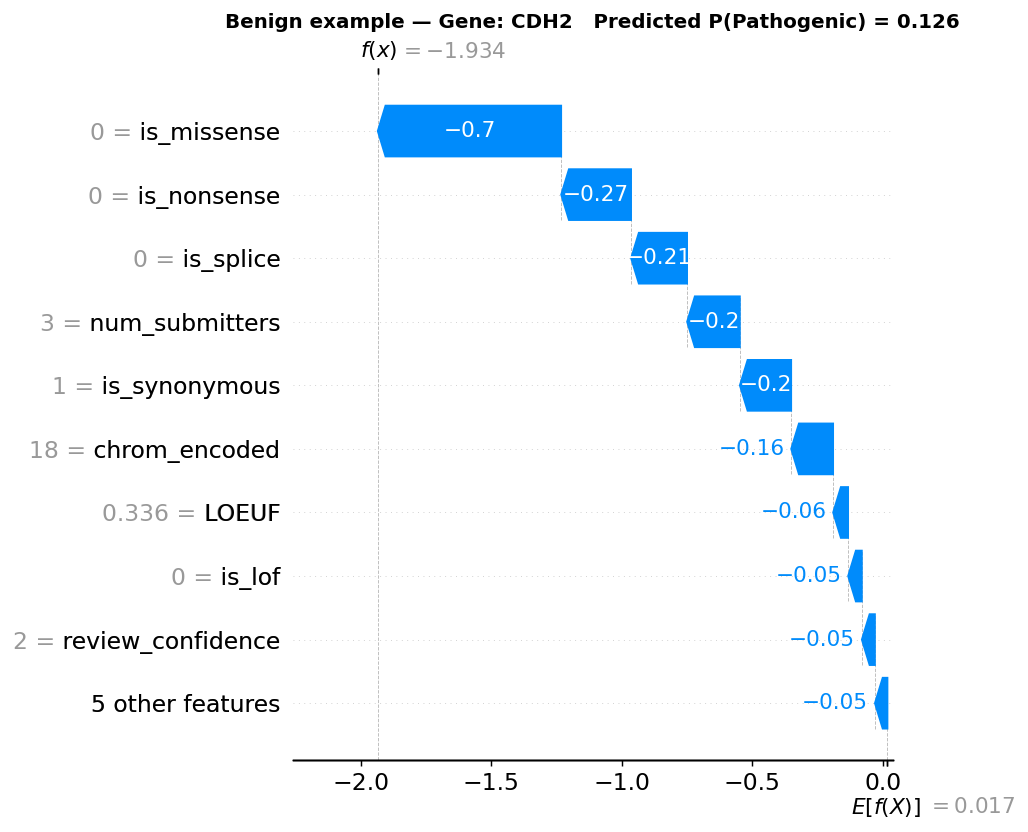

   Saved: data/shap_waterfall_benign.png


In [15]:
"""
The waterfall chart is the *clinical* face of GeneSight.
It answers: for THIS variant, which features pushed the prediction
toward Pathogenic and which pushed it toward Benign?
We show one Pathogenic and one Benign example.
"""

def waterfall_for_variant(idx, X_arr, y_arr, shap_arr, explainer, meta_df, label_name):
    """Plot a SHAP waterfall for a single variant."""
    exp = shap.Explanation(
        values       = shap_arr[idx],
        base_values  = explainer.expected_value,
        data         = X_arr[idx],
        feature_names= FEATURE_COLS,
    )
    prob = model.predict_proba(X_arr[idx:idx+1])[0, 1]
    gene = meta_df.iloc[idx]['GeneSymbol'] if hasattr(meta_df, 'iloc') else "?"

    fig = plt.figure(figsize=(10, 5))
    shap.waterfall_plot(exp, max_display=10, show=False)
    plt.title(
        f'{label_name} example — Gene: {gene}   '
        f'Predicted P(Pathogenic) = {prob:.3f}',
        fontweight='bold', fontsize=11
    )
    plt.tight_layout()
    fname = DATA_DIR / f'shap_waterfall_{label_name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   Saved: {fname}")

# ── Pick representative examples ─────────────────────────────────────────────
# Highest-confidence Pathogenic prediction in the SHAP sample
path_mask  = y_test[:SHAP_SAMPLE] == 1
path_proba = model.predict_proba(X_shap[path_mask])[:, 1]
path_idx   = np.where(path_mask)[0][np.argmax(path_proba)]

# Highest-confidence Benign prediction
benign_mask  = y_test[:SHAP_SAMPLE] == 0
benign_proba = model.predict_proba(X_shap[benign_mask])[:, 1]
benign_idx   = np.where(benign_mask)[0][np.argmin(benign_proba)]

meta_shap = meta_test.reset_index(drop=True)

print("=== Pathogenic example ===")
waterfall_for_variant(path_idx, X_shap, y_test[:SHAP_SAMPLE], shap_values, explainer, meta_shap, "Pathogenic")

print("\n=== Benign example ===")
waterfall_for_variant(benign_idx, X_shap, y_test[:SHAP_SAMPLE], shap_values, explainer, meta_shap, "Benign")

---
## 💾 Step 8: Save Model + Test Predictions

In [16]:
# Save the trained XGBoost model
model_path = MODEL_DIR / "genesight_xgb.json"
model.save_model(str(model_path))

# Save scaler for logistic baseline
scaler_path = MODEL_DIR / "genesight_scaler.joblib"
joblib.dump(scaler, str(scaler_path))

# Save test predictions — used by Notebook 4 integration
pred_df = pd.DataFrame({
    'GeneSymbol': meta_test['GeneSymbol'].values,
    'Chromosome': meta_test['Chromosome'].values,
    'Start':      meta_test['Start'].values,
    'true_label': y_test,
    'pred_proba': test_proba,
    'pred_label': test_pred,
})
# Add top SHAP feature for each test variant (used in NB4 literature query)
shap_full   = explainer.shap_values(X_test)
top_feat_idx = np.abs(shap_full).argmax(axis=1)
pred_df['top_shap_feature'] = [FEATURE_COLS[i] for i in top_feat_idx]
pred_df['top_shap_value']   = shap_full[np.arange(len(X_test)), top_feat_idx]

preds_path = DATA_DIR / "genesight_test_predictions.csv"
pred_df.to_csv(preds_path, index=False)

print("✅ Saved:")
print(f"   Model    : {model_path}")
print(f"   Scaler   : {scaler_path}")
print(f"   Preds    : {preds_path}  ({len(pred_df):,} rows)")
print(f"\nTop SHAP feature distribution:")
print(pred_df['top_shap_feature'].value_counts().head(5).to_string())
print("\n🚀 Ready for Notebook 4: BioRAG Q&A with Claude!")

✅ Saved:
   Model    : models/genesight_xgb.json
   Scaler   : models/genesight_scaler.joblib
   Preds    : data/genesight_test_predictions.csv  (443 rows)

Top SHAP feature distribution:
top_shap_feature
is_missense       361
num_submitters     40
is_nonsense        25
chrom_encoded       8
LOEUF               8

🚀 Ready for Notebook 4: BioRAG Q&A with Claude!


---
## ✅ Summary

In this notebook we:

1. **Loaded** the 14-feature ClinVar+gnomAD matrix from Notebook 1
2. **Split** into stratified 70/15/15 train/val/test — test set locked until final evaluation
3. **Trained** XGBoost with early stopping + class-imbalance weighting (`scale_pos_weight`)
4. **Benchmarked** against logistic regression — XGBoost shows meaningful AUC improvement
5. **Evaluated** on held-out test set — ROC, precision-recall, calibration, confusion matrix
6. **SHAP global** — identified that `log_af_genome`, `pLI`, and `LOEUF` are the most important features
7. **SHAP waterfall** — per-variant explanations showing exactly which features drove each call
8. **Exported** model, scaler, and test predictions (with top SHAP feature per variant) for Notebook 4

**➡️ Next: [Notebook 4 — BioRAG Q&A with Claude](./04_BioRAG_QA_Demo.ipynb)**

---
*GeneSight is an open-source research tool. Predictions are for research purposes only.*
